In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make charts clean and readable
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

In [2]:
# Loading raw data
df = pd.read_csv('raw_jobs.csv')

# Quick check on the dataset shape
print(f"Loaded {df.shape[0]} rows and {df.shape[1]} columns.")
df.head(3)

Loaded 17880 rows and 18 columns.


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0


### Column Mapping and Pre-Processing

In [3]:
# Standardize names for consistency
rename_dict = {
    'title': 'job_title',
    'company_profile': 'company',
    'description': 'job_description',
    'required_experience': 'experience',
    'required_education': 'education',
    'salary_range': 'salary',
    'employment_type': 'job_type'
}

df.rename(columns=rename_dict, inplace=True)

# Ensure job_description is clean string type
df['job_description'] = df['job_description'].fillna("").astype(str)

### Calculating Total and Unique Job Counts

In [4]:
# Total job count
total_jobs = len(df)
print(f"Total Number of Jobs: {total_jobs}")

# Unique titles count
unique_roles = df['job_title'].nunique()
print(f"Unique Job Titles: {unique_roles}")

Total Number of Jobs: 17880
Unique Job Titles: 11231


### Most Common Job Roles

In [5]:
# Frequency of top job titles
top_roles = df['job_title'].value_counts().head(10)
top_roles

job_title
English Teacher Abroad                                311
Customer Service Associate                            146
Graduates: English Teacher Abroad (Conversational)    144
English Teacher Abroad                                 95
Software Engineer                                      86
English Teacher Abroad (Conversational)                83
Customer Service Associate - Part Time                 76
Account Manager                                        75
Web Developer                                          66
Project Manager                                        62
Name: count, dtype: int64

### Jobs by location

In [6]:
# Distribution by location
top_locations = df['location'].value_counts().head(10)
top_locations

location
GB, LND, London          718
US, NY, New York         658
US, CA, San Francisco    472
GR, I, Athens            464
US, ,                    339
US, TX, Houston          269
US, IL, Chicago          255
US, DC, Washington       251
DE, BE, Berlin           221
NZ, N, Auckland          218
Name: count, dtype: int64

### Description length Metrics

In [7]:
# Calculating length of each description
df['description_length'] = df['job_description'].str.len()

# Statistical summary of lengths
avg_len = df['description_length'].mean()
min_len = df['description_length'].min()
max_len = df['description_length'].max()

print(f"Average Description Length: {avg_len:.2f} characters")
print(f"Minimum Description Length: {min_len} characters")
print(f"Maximum Description Length: {max_len} characters")

# Detailed distribution table
df['description_length'].describe().round(2)

Average Description Length: 1218.00 characters
Minimum Description Length: 0 characters
Maximum Description Length: 14907 characters


count    17880.00
mean      1218.00
std        894.83
min          0.00
25%        607.00
50%       1017.00
75%       1586.00
max      14907.00
Name: description_length, dtype: float64

### Missing Values & Duplicate Records

In [8]:
# Total duplicate rows
exact_duplicates = df.duplicated().sum()
print(f"Total Duplicate Records: {exact_duplicates}")

# Missing values per column
missing_summary = df.isnull().sum()
missing_summary = missing_summary[missing_summary > 0].sort_values(ascending=False)
missing_summary

Total Duplicate Records: 0


salary          15012
department      11547
education        8105
benefits         7212
experience       7050
function         6455
industry         4903
job_type         3471
company          3308
requirements     2696
location          346
dtype: int64

# Visualizations Starts from here:

### Top Job Titles

C:\Users\K Shridharan\AppData\Local\Temp\ipykernel_13688\1678071241.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


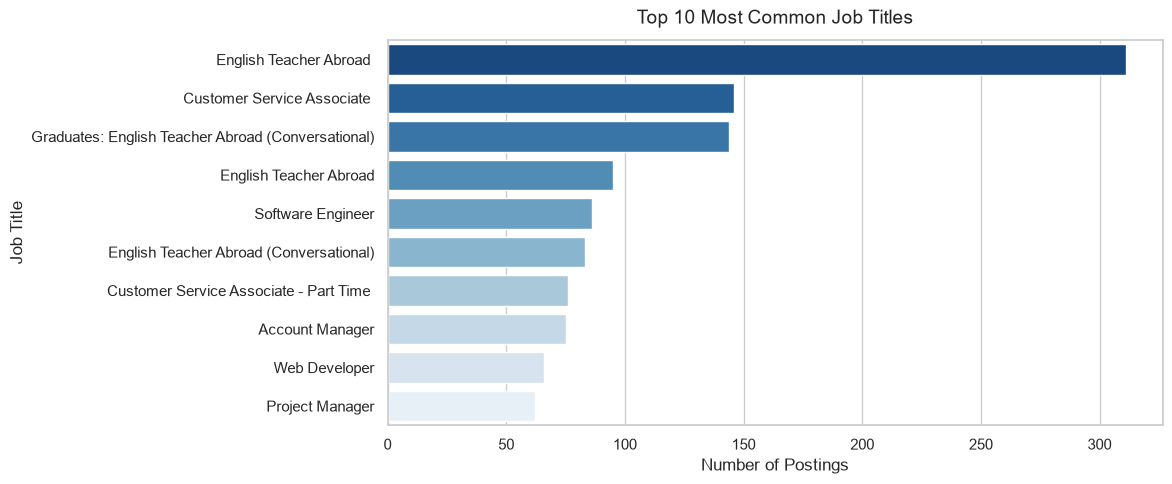

In [9]:
plt.figure(figsize=(10, 5))
sns.barplot(
    x=top_roles.values,
    y=top_roles.index,
    palette="Blues_r"
)
plt.title("Top 10 Most Common Job Titles", fontsize=14, pad=12)
plt.xlabel("Number of Postings")
plt.ylabel("Job Title")
plt.show()

### Jobs by location

C:\Users\K Shridharan\AppData\Local\Temp\ipykernel_13688\3971209698.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


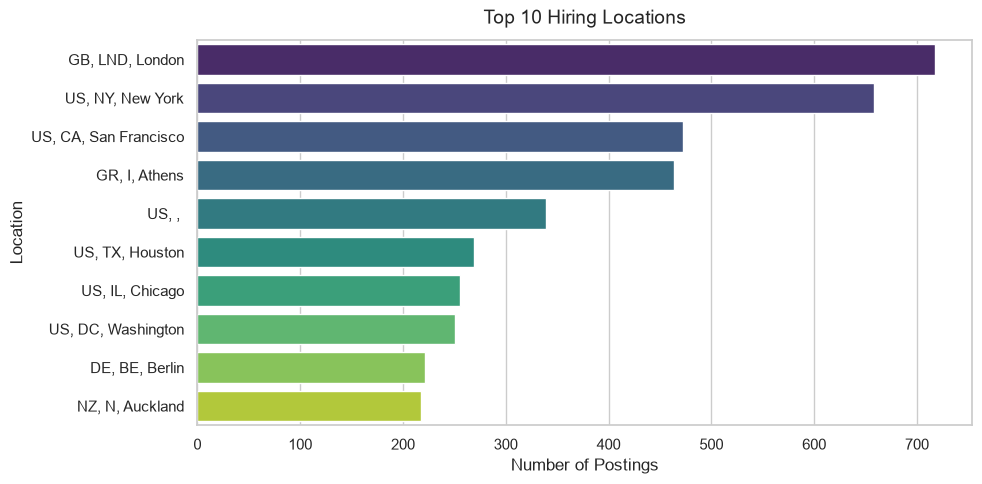

In [10]:
plt.figure(figsize=(10, 5))
sns.barplot(
    x=top_locations.values,
    y=top_locations.index,
    palette="viridis"
)
plt.title("Top 10 Hiring Locations", fontsize=14, pad=12)
plt.xlabel("Number of Postings")
plt.ylabel("Location")
plt.show()

### Description Length Distribution

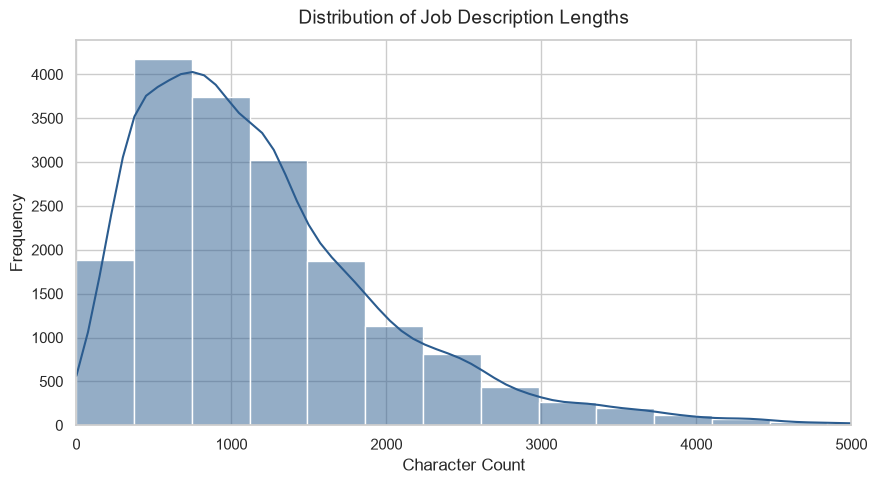

In [11]:
plt.figure(figsize=(10, 5))
sns.histplot(
    df['description_length'],
    bins=40,
    kde=True,
    color="#2b5c8f"
)
plt.title("Distribution of Job Description Lengths", fontsize=14, pad=12)
plt.xlabel("Character Count")
plt.ylabel("Frequency")
plt.xlim(0, 5000)  # Focus on the dense distribution zone
plt.show()

### Missing Values Overview

C:\Users\K Shridharan\AppData\Local\Temp\ipykernel_13688\702423376.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


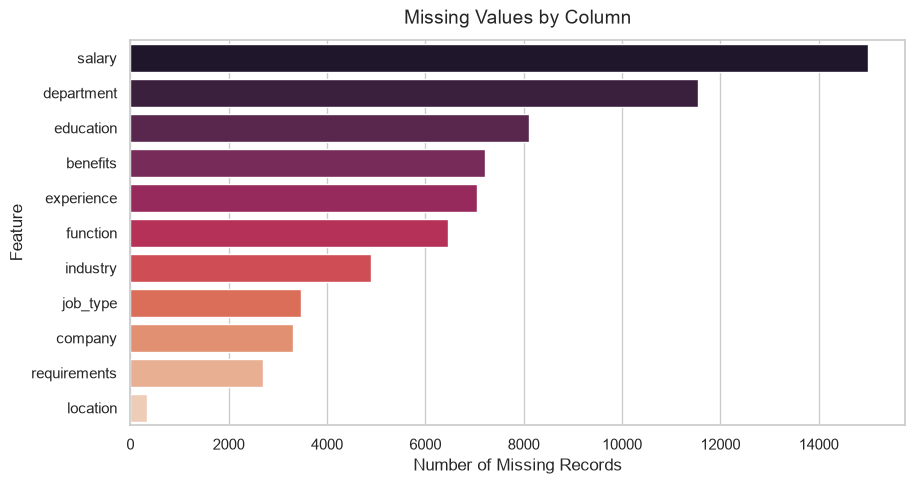

In [12]:
plt.figure(figsize=(10, 5))
sns.barplot(
    x=missing_summary.values,
    y=missing_summary.index,
    palette="rocket"
)
plt.title("Missing Values by Column", fontsize=14, pad=12)
plt.xlabel("Number of Missing Records")
plt.ylabel("Feature")
plt.show()

### Top Hiring Departments / Industries

C:\Users\K Shridharan\AppData\Local\Temp\ipykernel_13688\4112728669.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


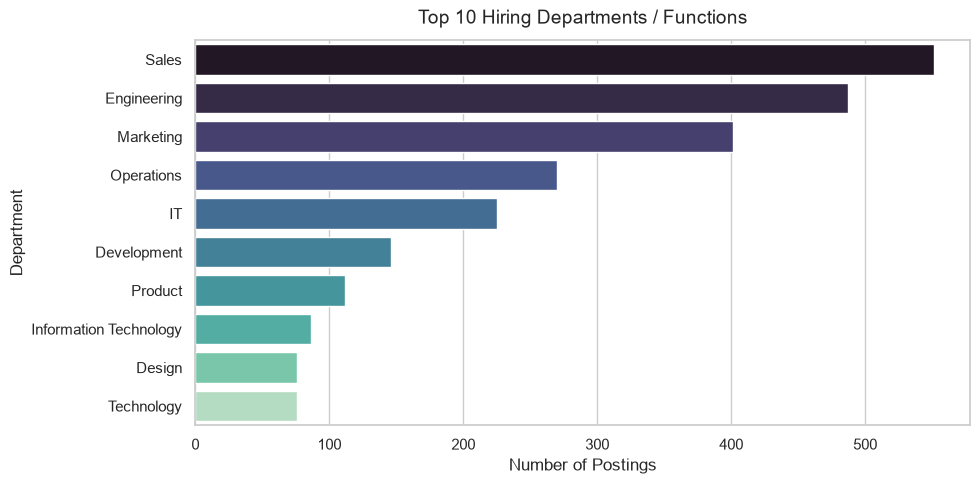

In [13]:
plt.figure(figsize=(10, 5))
top_depts = df['department'].value_counts().head(10)

sns.barplot(
    x=top_depts.values,
    y=top_depts.index,
    palette="mako"
)
plt.title("Top 10 Hiring Departments / Functions", fontsize=14, pad=12)
plt.xlabel("Number of Postings")
plt.ylabel("Department")
plt.show()